# Regresión lineal univariada

La regresión lineal crea una relación continua y lineal entre algunos datos de entrada y la salida conocida correspondiente. Calcular esta relación lineal conduce a un problema clásico de mínimos cuadrados. En términos más simples, tenemos datos de entrada en una matriz $X$ y datos de salida en un vector (o matriz) $y$, y queremos encontrar los coeficientes $\theta$ de manera que:

$$
X\theta = y
$$

Donde

$$
X = 
\begin{pmatrix}
1 & x^{(1)} \\
1 & x^{(2)} \\
\vdots & \vdots \\
1 & x^{(m)}
\end{pmatrix}, \quad
\theta =
\begin{pmatrix}
\theta_0 \\
\theta_1
\end{pmatrix}, \quad
y = 
\begin{pmatrix}
y^{(1)} \\
y^{(2)} \\
\vdots \\
y^{(m)}
\end{pmatrix}.
$$

La solución podría ser tan simple como $\theta = X^{-1}y$. Sin embargo, en la mayoría de los casos prácticos, $X$ no es invertible.

Considere el sigueiente ejemplo donde se desea vender una casa de 1000 m cuadrados y queremos estimar su precio esperado. De este modo, consultamos algunas bases de datos en línea y encontramos información existente sobre casas vendidas anteriormente. Con esta información construimos la siguente tabla:

| Tamaño ($m^2$) | Precio (USD) |
|:--------------:|:------------:|
|       820      |     70000    |
|       910      |     83000    |
|      1100      |     75000    |
|      1100      |     93000    |
|      1400      |     90000    |
|      1400      |     80000    |
|      1500      |     85000    |
|      1600      |    114000    |
|      1804      |    150000    |
|      2010      |    160050    |
|      2040      |    170000    |
|      2500      |    175000    |
|      3200      |    180000    |
|      3400      |    190000    |


Tenemos entonces datos pareados formados por el tamaño de la casa (los datos de entrada) y el precio de venta (etiqueta correspondiente). En otras palabras, tenemos la entrada adecuada a un algoritmo supervisado y ahora queremos llegar a una relación (por ahora, lineal) para hacer predicciones para cualquier tamaño de casa. Podemos decir entonces que la columna de precios está "supervisando" el proceso de aprendizaje.

Usando la información en la tabla podemos plantear un modelo matemático estableciendo la relación lineal $y = \theta_0 + \theta_1 x$. Donde $\theta_0$ y $\theta_1$ son las constanes que debemos encontrar. Para esto generamos el sistema de ecuaciones dado por $y^{(i)} = (1, x^{(i)})(\theta_0, \theta_1)^T$, en su forma matricial $X\theta = y$ tenemos:

$$
\begin{pmatrix}
1 & 820 \\
1 & 910 \\
1 & 1100 \\
\vdots & \vdots \\
1 & 3200 \\
1 & 3400
\end{pmatrix}
\begin{pmatrix}
\theta_0 \\
\theta_1
\end{pmatrix} =
\begin{pmatrix}
70000 \\
83000 \\
75000 \\
\vdots \\
180000 \\
190000
\end{pmatrix}.
$$

Tenga en cuenta que se debe extender la matriz $X$ para incluir una primera columna de terminos unitatios. Esto se encarga de la constante de intersección $\theta_0$. Esta intersección también se conoce como el término de sesgo (bias). Claramente, este sistema no tiene una solución ya que el vector $y$ no está en el rango de $X$ (extendida). Es decir, que no existen valores fijos para $\theta_0$ y $\theta_1$ que produzcan igualdad para todos los elementos en el lado izquierdo y derecho de la ecuación.

Antes de continuar es importante visualizar los datos con el fin de contextualizar el problema. Los siguentes bloques de código en Python generan un diagrama de dispersión de los puntos.

In [1]:
# requirements
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('ggplot')

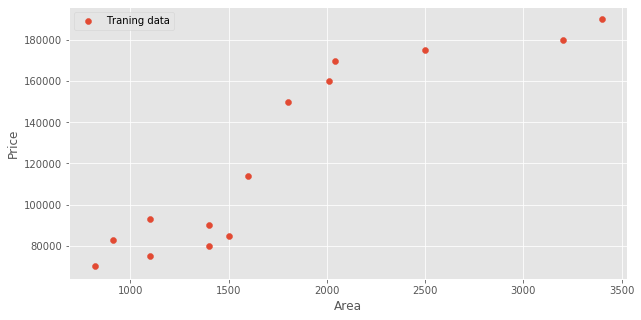

In [2]:
# Data
x = np.array([820, 910, 1100, 1100, 1400, 1400, 1500, 1600, 1804, 2010, 2040, 2500, 3200, 3400]).reshape(14, 1)
y = np.array([70000, 83000, 75000, 93000, 90000, 80000, 85000, 114000, 150000, 160050, 170000, 175000, 180000, 190000]).reshape(14, 1)

plt.figure(figsize=(10, 5))
plt.scatter(x, y, label="Traning data")
plt.xlabel("Area")
plt.ylabel("Price")
plt.legend()
plt.show()

Buscamos entonces un modelo lineal que se ajusute a la tendencia de los puntos. Como los puntos no están alineados, no hay una sola línea que pase por todos los puntos. Lo mejor que podemos hacer es minimizar el error total entre el precio de la vivienda $y^{(i)}$ y el modelo $h(\theta, \mathbf{x}^{(i)}) = \mathbf{x}^{(i)T}\theta$ para cada punto. Esto es minimizar

$$
\sum_{i = 1}^m \left(h(\theta, \mathbf{x}^{(i)}) - y^{(i)}\right)^2 = \sum_{i = 1}^m \left(\mathbf{x}^{(i)T}\theta - y^{(i)}\right)^2 = \|X\theta - y\|^2
$$

Seleccionando valores apropiados para $\theta_0$ y $\theta_1$. 

A continuació se presentan los métodos mas usados para la selección de $\theta_0$ y $\theta_1$

# Método de ecuaciones normales

Las ecuaciones normales estan definidas por:
$$
X^T X\theta = X^T y,
$$

de las cuales obtenemos $\theta$ despejando

$$
\theta = (X^T X)^{-1} X^T y.
$$

Retomando el ejemplo de las casas, tenemos:

In [3]:
bias = np.ones((14, 1))
X = np.hstack((bias, x))

A = X.T @ X
Ainv = np.linalg.inv(A)
b = X.T @ y
theta = Ainv @ b
print("theta = \n", theta)

theta = 
 [[30994.74367923]
 [   51.69155861]]


Una vez que calculamos los parametros $\theta$ podemos usarlos para predecir cualquier nueva $y$. Esta predicción se llama hipótesis en la comunidad ML. Denotamos la hipótesis como un sistema que, una vez que aprendió $\theta$, puede construir nuevas estimaciones para cualquier tamaño de casa $x$ usando

$$
h(\theta, \mathbf{x}) = \mathbf{x}^T\theta = 
\begin{pmatrix}
1 & x
\end{pmatrix}
\begin{pmatrix}
\theta_0 \\
\theta_1
\end{pmatrix}
$$

Ahora podemos estimar el precio de la casa que se desea vender. Dado que la casa considerada en el ejemplo tiene 1000 metros cuadrados, su precio de venta esta dado por:

In [4]:
xp = np.array([[1], [1000]])
P = xp.T @ theta
print("Price estimaton = ", P)

Price estimaton =  [[82686.30228522]]


Podemos tambien observar el ajuste del modelo a nuestros datos en el siguente gráfico

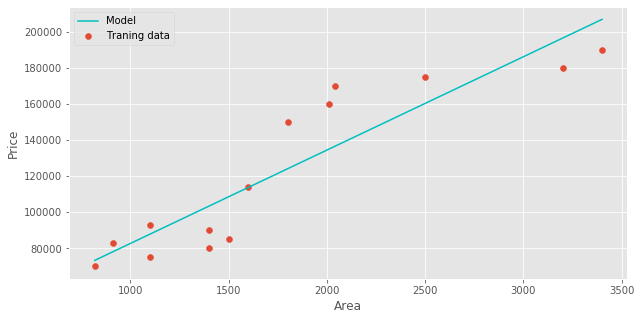

In [5]:
# Model
h = theta[0] + theta[1]*x

plt.figure(figsize=(10, 5))
plt.scatter(x, y, label="Traning data")
plt.plot(x, h, 'c', label="Model")
plt.xlabel("Area")
plt.ylabel("Price")
plt.legend()
plt.show()